# Base Model Notebook

The goal of this notebook is to build a model from scratch and identify key components and insights that will be useful for developing more complex models.

### Imports

In [43]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, Sequential
from keras.utils import image_dataset_from_directory

# model building imports
from keras import Model, Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, RandAugment, GlobalAveragePooling2D, GlobalMaxPool2D, Dropout, RandomRotation, RandomFlip
from keras.optimizers import SGD, Adam
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score
from keras.callbacks import EarlyStopping

#Model Class
from keras import Model

#Our custom augmentations
from augmentation import (
    augmentation_conservative,
    augmentation_mild,
    augmentation_moderate,
    augmentation_moderate_plus,
    augmentation_aggressive,
    augmentation_moderate_noise,
)

In [10]:
Train_Path = "Data/Train"
Validation_Path = "Data/Validation"

Input_shape = (124,124,3) #We will use 124 x 124 just because we are testing and we want the training to be faster
Batch_size = 64

We will define our evaluation metrics right now, so we don't have to define it in each model created

In [13]:

# metrics
categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")
metrics = [categorical_accuracy, auc, f1_score]

Importing the Train and Validation set

In [5]:
train_df = image_dataset_from_directory(
    Train_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= Input_shape,
    batch_size=Batch_size
)

Found 9329 files belonging to 23 classes.


I0000 00:00:1776706598.282585   23154 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5146 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [6]:
val_df = image_dataset_from_directory(
    Validation_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= Input_shape,
    batch_size=Batch_size
)

Found 1999 files belonging to 23 classes.


## First Model

In [11]:
class First_Model(Model):
    """
    A First model, with a very simple arquitecture that we can build on.
    It has 2 convolutional Blocks with 2 Max Pooling layers, a Flatten layer and 2 Dense Layers

    """
    #Initialization
    def __init__(self):
        super().__init__(name="First_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        self.Flatten_layer = Flatten()
        self.Dense_1 = Dense(100, activation="relu")
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x)                               
        x = self.Flatten_layer(x)                                       
        x = self.Dense_1(x)
        x = self.Dense_2(x)

        return x

In [21]:
#Get the summary of the model

first_model = First_Model()
inputs = Input(shape=Input_shape)
_ = first_model.call(inputs)
first_model.summary()

Model: "First_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 122, 122, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 61, 61, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 59, 59, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 29, 29, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 20184)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │     2,018,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,026,703 (7.73 MB)

 Trainable params: 2,026,703 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Defining the optimizer, the loss and the number of epochs

optimizer = SGD(learning_rate=0.01, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 20

In [23]:
first_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [ ]:
first_model_results = first_model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)


Epoch 1/20


I0000 00:00:1776723493.443135   24750 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19156__.47


143/146 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2804 - auc: 0.7991 - f1_score: 0.2540 - loss: 3.0638

I0000 00:00:1776723497.380956   24747 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19156__.47


146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.2280 - auc: 0.7505 - f1_score: 0.1948 - loss: 3.0168 - val_accuracy: 0.1191 - val_auc: 0.6621 - val_f1_score: 0.0224 - val_loss: 2.9660
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1659 - auc: 0.6908 - f1_score: 0.0489 - loss: 2.8821 - val_accuracy: 0.1561 - val_auc: 0.6985 - val_f1_score: 0.0470 - val_loss: 2.8651
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1944 - auc: 0.7290 - f1_score: 0.0879 - loss: 2.7807 - val_accuracy: 0.1846 - val_auc: 0.7341 - val_f1_score: 0.0870 - val_loss: 2.7698
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2244 - auc: 0.7641 - f1_score: 0.1256 - loss: 2.6707 - val_accuracy: 0.2246 - val_auc: 0.7592 - val_f1_score: 0.1459 - val_loss: 2.6848
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2543 - auc: 0.7897 - f1_score: 0.1628 - loss: 2.5581 - val_accuracy: 0.2411 - val_auc: 0.7754 - val_f1_score: 0.1624 - val_loss: 2.6

In [25]:
#Function to plot the metrics for better evaluation
def plot_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train')
    axes[0, 0].plot(history.history['val_loss'], label='Val')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0,0].set_ylim(bottom=0)
    axes[0, 0].legend()

    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train')
    axes[0, 1].plot(history.history['val_accuracy'], label='Val')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0,1].set_ylim(bottom=0)
    axes[0, 1].legend()

    # F1 Score
    axes[1, 0].plot(history.history['f1_score'], label='Train')
    axes[1, 0].plot(history.history['val_f1_score'], label='Val')
    axes[1, 0].set_title('F1 Score')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1,0].set_ylim(bottom=0)
    axes[1, 0].legend()

    # AUC
    axes[1, 1].plot(history.history['auc'], label='Train')
    axes[1, 1].plot(history.history['val_auc'], label='Val')
    axes[1, 1].set_title('AUC')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1,1].set_ylim(bottom=0)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

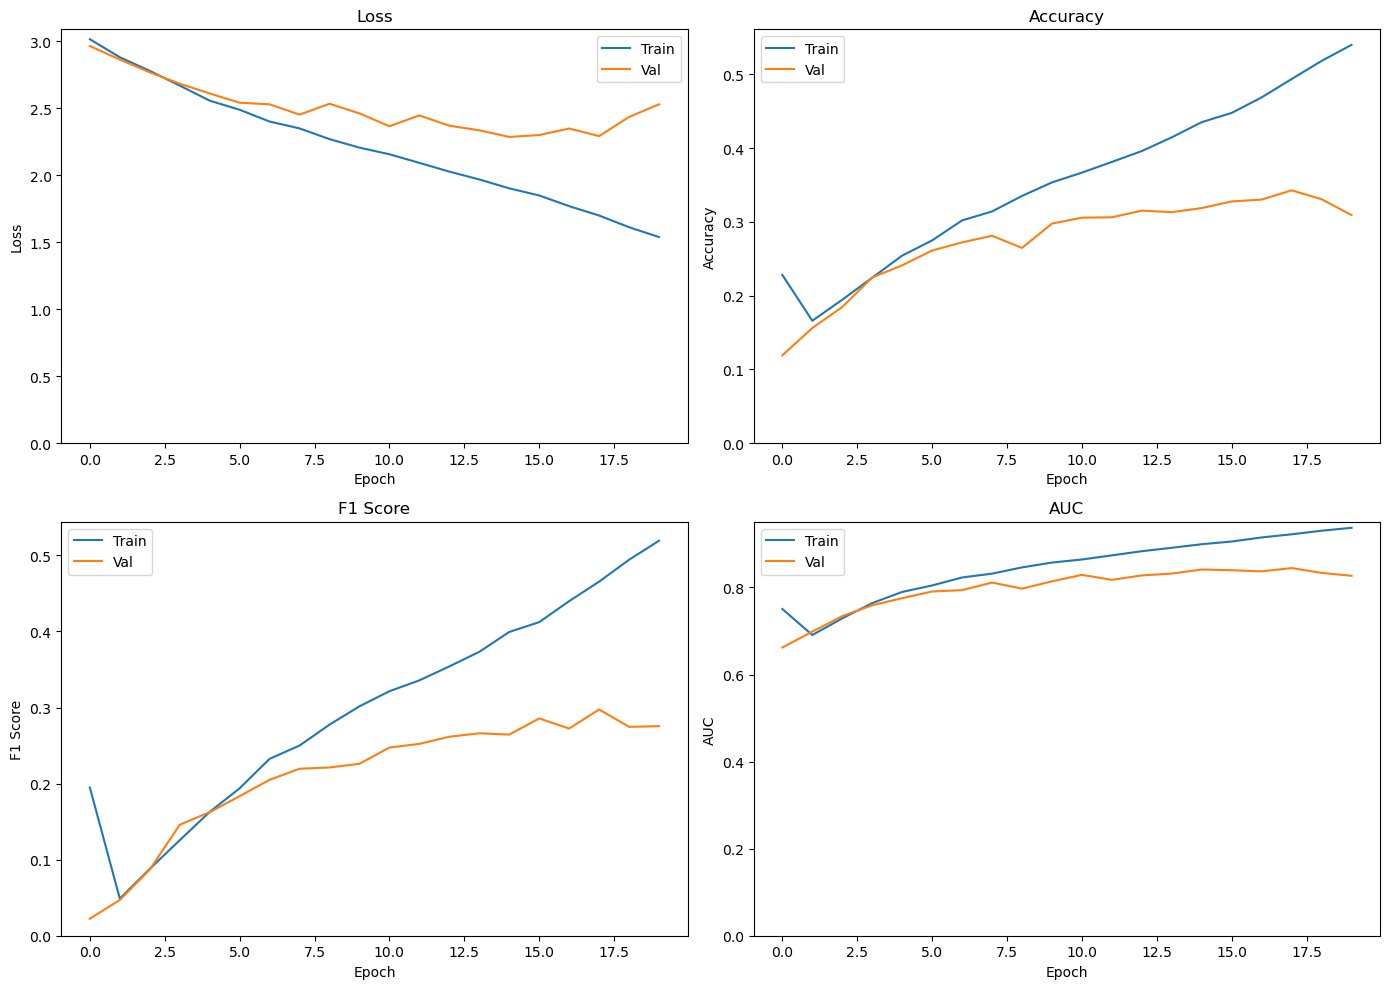

In [26]:
plot_history(first_model_results)

The results were as expected, the f1 score was not the best in train and val even with 20 epochs. The model also overfitted a lot, in the last 3 epochs the models could not reduse loss.

In the next step in order to try to increase performance and for the model to converge faster, we decided to switch the optimizer to Adam.

## First Model with Adam

In [36]:
first_model_adam = First_Model()


In [37]:
#We will decrease the learning rate because Adam is much more sensitive than SGD
optimizer= Adam(learning_rate=0.001, name="optimizer")

In [38]:
first_model_adam.compile(optimizer=optimizer,loss=loss,metrics=metrics)

In [ ]:
first_model_adam_results = first_model_adam.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/20


I0000 00:00:1776724663.425165   24746 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99698__.47


142/146 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1372 - auc: 0.6557 - f1_score: 0.0494 - loss: 2.9332

I0000 00:00:1776724667.650173   24745 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99698__.47


146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.1755 - auc: 0.7033 - f1_score: 0.0866 - loss: 2.7683 - val_accuracy: 0.2711 - val_auc: 0.7763 - val_f1_score: 0.1713 - val_loss: 2.5830
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3252 - auc: 0.8344 - f1_score: 0.2653 - loss: 2.3282 - val_accuracy: 0.3167 - val_auc: 0.8247 - val_f1_score: 0.2543 - val_loss: 2.3679
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4130 - auc: 0.8840 - f1_score: 0.3693 - loss: 2.0113 - val_accuracy: 0.3487 - val_auc: 0.8446 - val_f1_score: 0.2922 - val_loss: 2.2617
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5001 - auc: 0.9206 - f1_score: 0.4687 - loss: 1.7038 - val_accuracy: 0.3337 - val_auc: 0.8392 - val_f1_score: 0.3045 - val_loss: 2.3523
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5905 - auc: 0.9501 - f1_score: 0.5705 - loss: 1.3768 - val_accuracy: 0.3467 - val_auc: 0.8369 - val_f1_score: 0.3044 - val_loss: 2.4

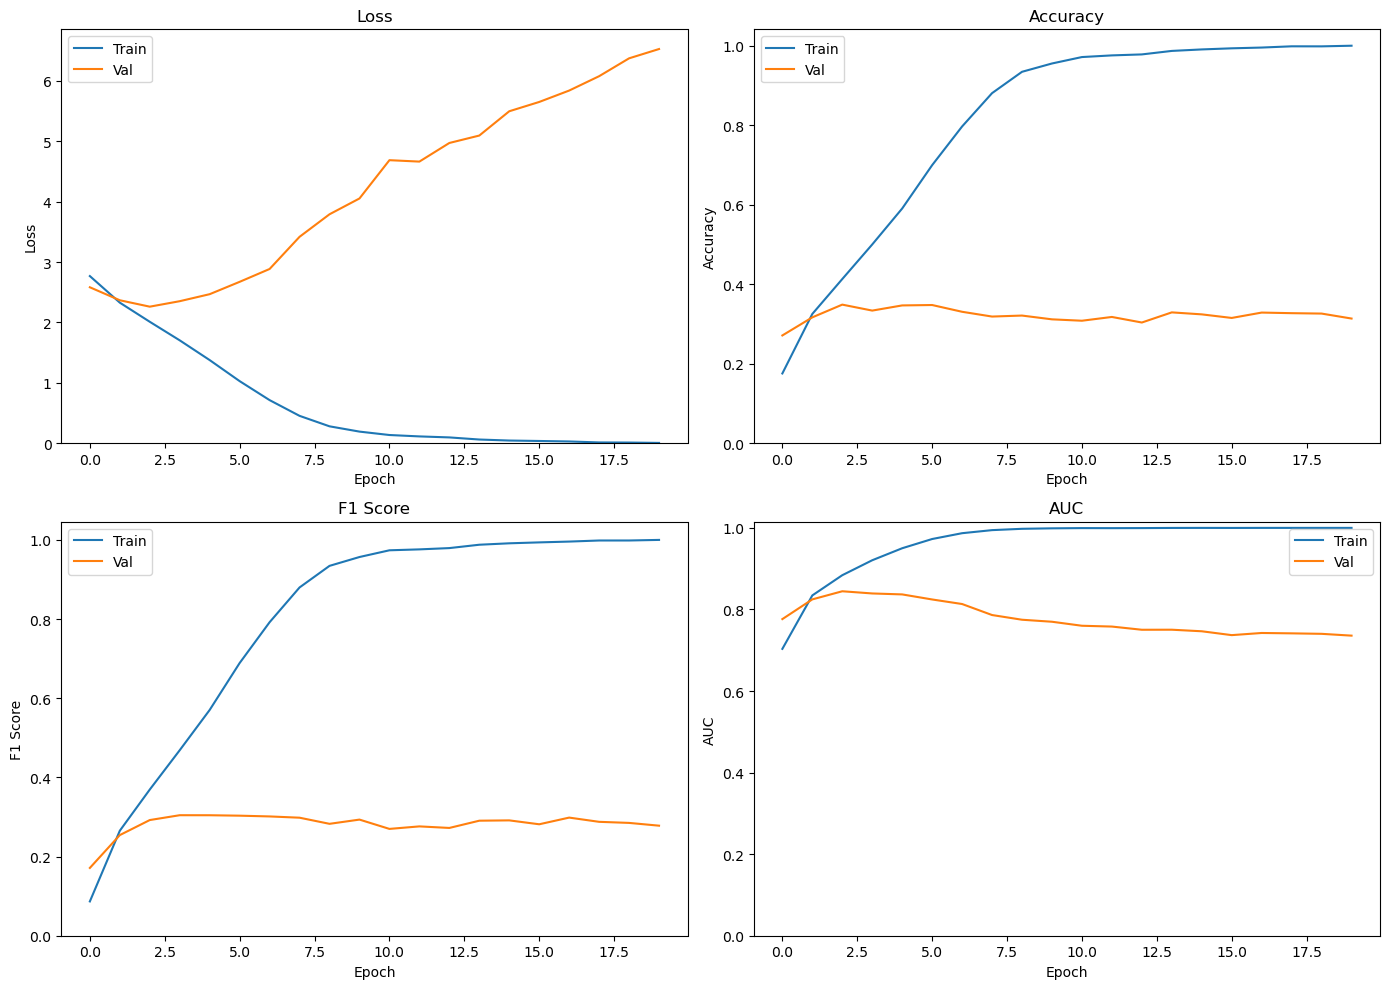

In [40]:
plot_history(first_model_adam_results)

The performance of the model generaly improved, and the model converged ultra fast, but we have a lot of over fitting, the scores are very high in the training set and very bad in the validation data set, so we have to do something about it.

In the next setp we will try adding augmentations and drop out in order to reduce overfitting

## Base model with Augmentations and Dropout

In [55]:
class Augmented_Model(Model):
    """
    Using augmentation techniques and dropout to reduce overfitting.

    """
    #Initialization
    def __init__(self):
        super().__init__(name="Augmented_Model")

        self.n_classes = 23
        self.Rescaling = Rescaling(1./255)
        self.augmentation_layer = augmentation_moderate

        #First Convolutional Block
        self.Conv1 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_1"
        )

        #First Pooling Layer
        self.max_pool_layer_1 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_1"
        )


        #Second Convolutional Block
        self.Conv2 = Conv2D(
            filters=24,
            kernel_size=(3, 3),
            activation="relu",
            name="conv_layer_2"
        )

        #Second Pooling Layer
        self.max_pool_layer_2 = MaxPooling2D(
            pool_size=(2, 2),
            name="max_pool_layer_2"
        )

        self.Flatten_layer = Flatten()
        self.Dense_1 = Dense(100, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)  
        x = self.augmentation_layer(x)
        x = self.Conv1(x)
        x = self.max_pool_layer_1(x)
        x = self.Conv2(x)
        x = self.max_pool_layer_2(x)                               
        x = self.Flatten_layer(x)                                       
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [56]:
#Get the summary of the model

Augmented_Model = Augmented_Model()
inputs = Input(shape=Input_shape)
_ = Augmented_Model.call(inputs)
Augmented_Model.summary()

Model: "Augmented_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ (None, 124, 124, 3)    │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 122, 122, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ (None, 61, 61, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 59, 59, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ (None, 29, 29, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 20184)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │     2,018,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,026,703 (7.73 MB)

 Trainable params: 2,026,703 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
optimizer = Adam(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs = 20

In [58]:
Augmented_Model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [59]:
Augmented_Model_results = Augmented_Model.fit(
    train_df,
    validation_data= val_df,
    epochs=epochs
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.2003 - auc: 0.7202 - f1_score: 0.1375 - loss: 2.8879 - val_accuracy: 0.2076 - val_auc: 0.7501 - val_f1_score: 0.1214 - val_loss: 2.7319
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.2515 - auc: 0.7918 - f1_score: 0.1792 - loss: 2.5511 - val_accuracy: 0.2576 - val_auc: 0.7962 - val_f1_score: 0.2007 - val_loss: 2.5242
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.3040 - auc: 0.8252 - f1_score: 0.2436 - loss: 2.3861 - val_accuracy: 0.2726 - val_auc: 0.8105 - val_f1_score: 0.2135 - val_loss: 2.4561
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3219 - auc: 0.8440 - f1_score: 0.2682 - loss: 2.2849 - val_accuracy: 0.3017 - val_auc: 0.8263 - val_f1_score: 0.2419 - val_loss: 2.3807
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3434 - auc: 0.8573 - f1_score: 0.2936 - loss: 2.2046 - val_accuracy: 0.3127 - val_auc: 0.8353 - val_f1_score: 0.2753 - va

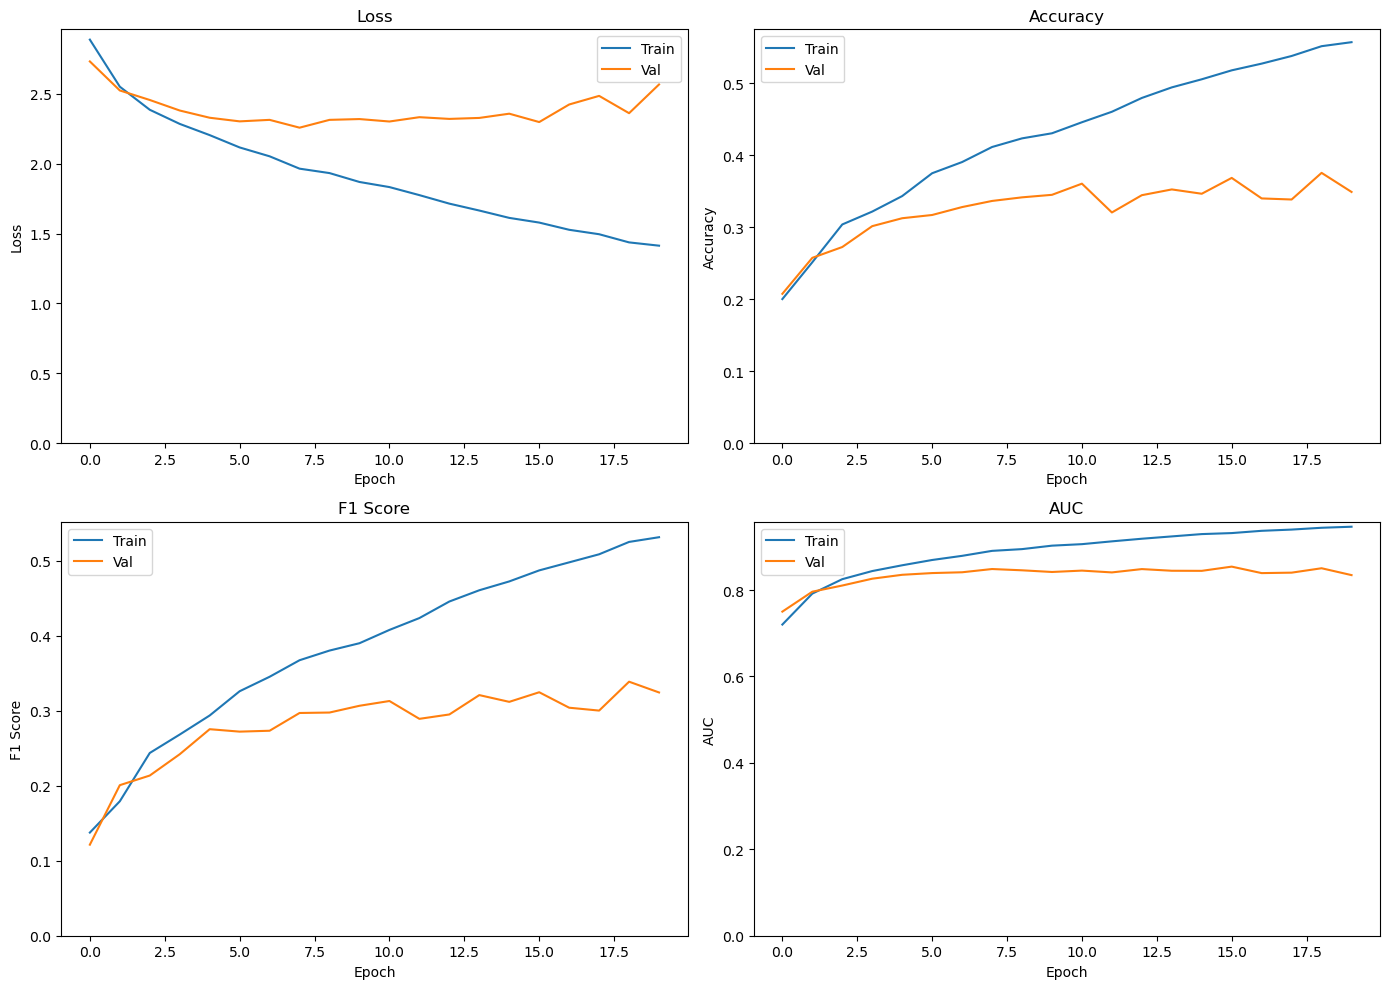

In [60]:
plot_history(Augmented_Model_results)